### Viscous Burgers' Equation
$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}$$




In [ ]:
import tensorflow as tf
import numpy as np

In [ ]:
def Burger_equation():
  return tf.keras.Sequential([
      tf.keras.layers.Input(shape=(2,)),
      tf.keras.layers.Dense(32, activation='tanh'),
      tf.keras.layers.Dense(32, activation='tanh'),
      tf.keras.layers.Dense(32, activation='tanh'),
      tf.keras.layers.Dense(1)
  ])

In [ ]:
#Viscosity constant
nu = 0.1 / np.pi

# Initial conditions t = 0, u(x,0) = -sin(pi * x)
x_ic = tf.random.uniform((50, 1), -1, 1)
t_ic = tf.zeros((50, 1))
u_ic_target = -tf.sin(np.pi * x_ic)

# Boundry conditions x = -1 and x = 1, u = 0 for all time
x_bc_left = -tf.ones((50,1))
x_bc_right = tf.ones((50,1))
t_bc = tf.random.uniform((50,1), 0, 1)
u_bc = tf.zeros((50,1))

# Collocation points
x_physics = tf.random.uniform((1000,1), -1,1)
t_physics = tf.random.uniform((1000,1), 0, 1)

In [ ]:
@tf.function
def train_step_burger(model, optimizer):
  with tf.GradientTape() as tape_model:

    # Calculate IC Loss
    inputs_ic = tf.concat([x_ic, t_ic], axis=1)
    u_ic_pred = model(inputs_ic)
    loss_ic = tf.reduce_mean(tf.square(u_ic_pred - u_ic_target))

    # Calculate BC Loss (left and right boundary)
    inputs_bc_left = tf.concat([x_bc_left, t_bc], axis=1)
    inputs_bc_right = tf.concat([x_bc_right, t_bc], axis=1)
    u_bc_pred_left = model(inputs_bc_left)
    u_bc_pred_right = model(inputs_bc_right)
    loss_bc = tf.reduce_mean(tf.square(u_bc_pred_left - u_bc)) + tf.reduce_mean(tf.square(u_bc_pred_right - u_bc))

    with tf.GradientTape(persistent=True) as tape_pde:
      tape_pde.watch(x_physics)
      tape_pde.watch(t_physics)

      with tf.GradientTape(persistent=True) as tape_1st_deriv:
        tape_1st_deriv.watch(x_physics)
        tape_1st_deriv.watch(t_physics)

        inputs = tf.concat([x_physics, t_physics], axis = 1)
        u_pred = model(inputs)

      u_x = tape_1st_deriv.gradient(u_pred, x_physics)
      u_t = tape_1st_deriv.gradient(u_pred, t_physics)

    u_xx = tape_pde.gradient(u_x, x_physics)

    del tape_1st_deriv
    del tape_pde

    pde_residual = u_t + (u_pred * u_x) - (nu * u_xx)
    loss_physics = tf.reduce_mean(tf.square(pde_residual))

    total_loss = loss_ic + loss_bc + loss_physics

  grads = tape_model.gradient(total_loss, model.trainable_variables)
  optimizer.apply_gradients(zip(grads, model.trainable_variables))

  return total_loss, loss_ic, loss_bc, loss_physics

In [ ]:
epochs = 5000

# Re-initialize the model for Burgers' equation
model = Burger_equation()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

print("Starting Training...")
for epoch in range(epochs):
    total_loss, loss_ic, loss_bc, loss_pde = train_step_burger(model, optimizer)

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | "
              f"Total: {total_loss:.3e} | "
              f"IC Loss: {loss_ic:.3e} | "
              f"BC Loss: {loss_bc:.3e} | "
              f"PDE Loss: {loss_pde:.3e}")

print("Training Complete!")

Starting Training...
Epoch    0 | Total: 5.047e-01 | IC Loss: 3.384e-01 | BC Loss: 1.594e-01 | PDE Loss: 6.978e-03
Epoch  500 | Total: 7.058e-03 | IC Loss: 1.891e-03 | BC Loss: 1.539e-03 | PDE Loss: 3.629e-03
Epoch 1000 | Total: 5.394e-04 | IC Loss: 9.749e-05 | BC Loss: 5.928e-05 | PDE Loss: 3.826e-04
Epoch 1500 | Total: 2.442e-04 | IC Loss: 3.971e-05 | BC Loss: 2.365e-05 | PDE Loss: 1.809e-04
Epoch 2000 | Total: 5.531e-04 | IC Loss: 1.301e-04 | BC Loss: 1.959e-04 | PDE Loss: 2.271e-04
Epoch 2500 | Total: 9.349e-05 | IC Loss: 1.577e-05 | BC Loss: 1.733e-05 | PDE Loss: 6.039e-05
Epoch 3000 | Total: 1.479e-03 | IC Loss: 3.402e-04 | BC Loss: 6.767e-04 | PDE Loss: 4.622e-04
Epoch 3500 | Total: 5.090e-03 | IC Loss: 7.041e-04 | BC Loss: 2.208e-03 | PDE Loss: 2.178e-03
Epoch 4000 | Total: 5.241e-05 | IC Loss: 1.200e-05 | BC Loss: 7.995e-06 | PDE Loss: 3.242e-05
Epoch 4500 | Total: 4.714e-05 | IC Loss: 6.935e-06 | BC Loss: 9.019e-06 | PDE Loss: 3.118e-05
Training Complete!


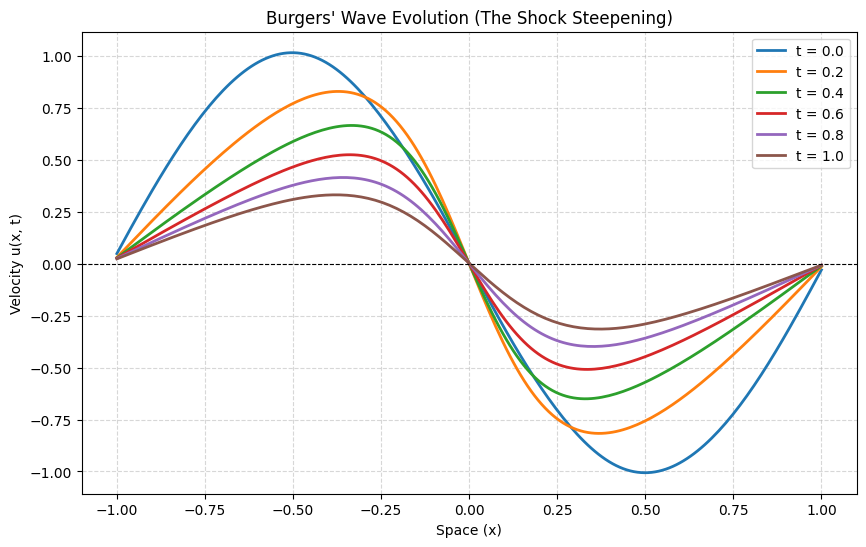

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Select specific time slices to show how the wave evolves
t_slices = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
x_test = np.linspace(-1.0, 1.0, 200)

plt.figure(figsize=(10, 6))
for t_val in t_slices:
  # Create inputs for this specific time across all spatial points
  t_arr = np.full_like(x_test, t_val)
  inputs_slice = np.stack([x_test, t_arr], axis=-1).astype(np.float32)

  # Predict velocity profile
  u_slice = model.predict(inputs_slice, verbose=0)
  plt.plot(x_test, u_slice, label=f"t = {t_val:.1f}", linewidth=2)

plt.title("Burgers' Wave Evolution (The Shock Steepening)")
plt.xlabel("Space (x)")
plt.ylabel("Velocity u(x, t)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.show()

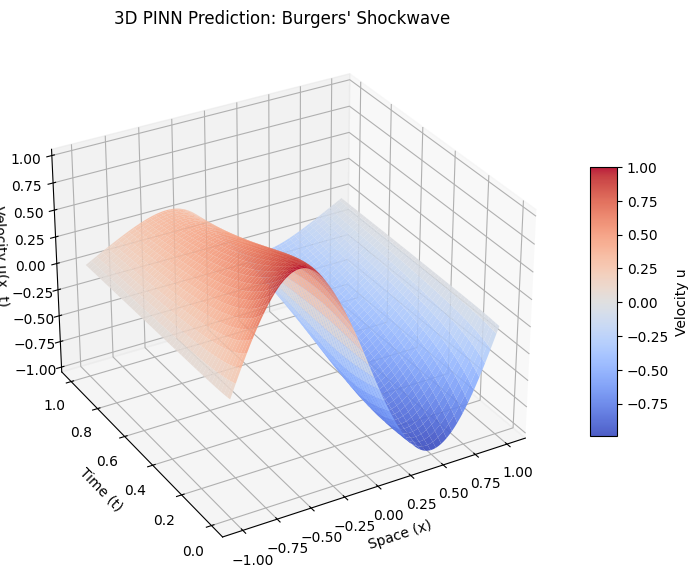

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(projection="3d")

# Plot the 3D surface
surf = ax.plot_surface(X, T, U_pred, cmap="coolwarm", edgecolor="none", alpha=0.9)

ax.set_title("3D PINN Prediction: Burgers' Shockwave")
ax.set_xlabel("Space (x)")
ax.set_ylabel("Time (t)")
ax.set_zlabel("Velocity u(x, t)")

# Add a color bar which maps values to colors
fig.colorbar(surf, shrink=0.5, aspect=10, label="Velocity u")

# Adjust viewing angle for maximum clarity
ax.view_init(elev=30, azim=-120)
plt.show()

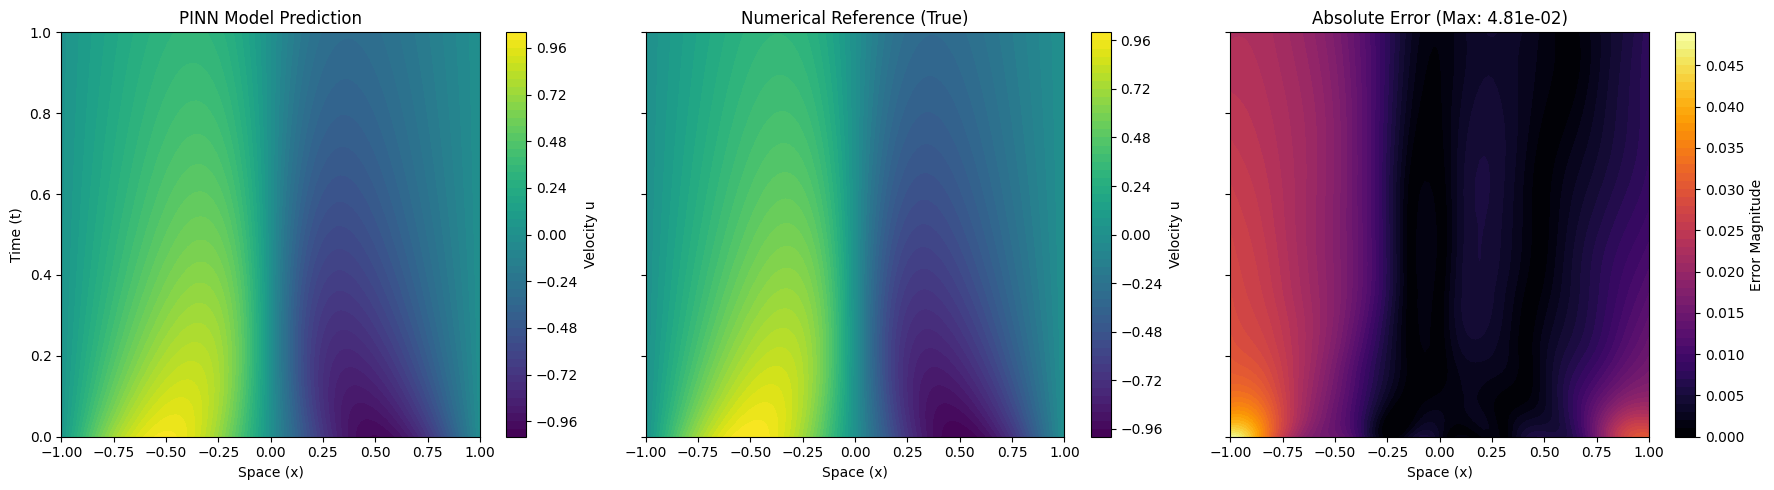

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import tensorflow as tf

# 1. Generate High-Resolution Grid for Comparison
x_test = np.linspace(-1.0, 1.0, 100)
t_test = np.linspace(0.0, 1.0, 100)
X, T = np.meshgrid(x_test, t_test)

# --- A. Get PINN Predictions ---
x_flat = X.flatten().reshape(-1, 1).astype(np.float32)
t_flat = T.flatten().reshape(-1, 1).astype(np.float32)
inputs_test = tf.concat([x_flat, t_flat], axis=1)
U_pred = model.predict(inputs_test, verbose=0).reshape(X.shape)


# --- B. Compute Numerical Reference Solution (Ground Truth) ---
def burgers_reference(x, t_span, nu):
  dx = x[1] - x[0]
  u0 = -np.sin(np.pi * x)

  def pde(t, u):
    du_dt = np.zeros_like(u)
    u_x = np.gradient(u, dx)
    u_xx = np.gradient(u_x, dx)
    du_dt[1:-1] = -u[1:-1] * u_x[1:-1] + nu * u_xx[1:-1]
    du_dt[0] = 0
    du_dt[-1] = 0
    return du_dt

  sol = solve_ivp(pde, [t_span[0], t_span[-1]], u0, t_eval=t_span, method="Radau")
  return sol.y.T


# Compute reference using your viscosity (nu = 0.1)
U_true = burgers_reference(x_test, t_test, nu=0.1)

# --- C. Calculate Error ---
absolute_error = np.abs(U_pred - U_true)

# 2. Plot the 3-Panel Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Panel 1: PINN Prediction
im0 = axes[0].contourf(X, T, U_pred, levels=50, cmap="viridis")
axes[0].set_title("PINN Model Prediction")
axes[0].set_xlabel("Space (x)")
axes[0].set_ylabel("Time (t)")
fig.colorbar(im0, ax=axes[0], label="Velocity u")

# Panel 2: Ground Truth
im1 = axes[1].contourf(X, T, U_true, levels=50, cmap="viridis")
axes[1].set_title("Numerical Reference (True)")
axes[1].set_xlabel("Space (x)")
fig.colorbar(im1, ax=axes[1], label="Velocity u")

# Panel 3: Absolute Error Difference
im2 = axes[2].contourf(X, T, absolute_error, levels=50, cmap="inferno")
axes[2].set_title(
    f"Absolute Error (Max: {np.max(absolute_error):.2e})"
)
axes[2].set_xlabel("Space (x)")
fig.colorbar(im2, ax=axes[2], label="Error Magnitude")

plt.tight_layout()
plt.show()